In [18]:
# Import libraries

import json
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mafese import Data

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression  # Just for evaluating during feature selection
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, roc_curve


from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [19]:
# Load Dataset
df = pd.read_csv('creditcard_2023.csv')

# Optional: Drop 'id' column if present
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Shuffle the data to mix Class 0 and Class 1
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Prepare features and labels
X = df.drop('Class', axis=1)  # Features
y = df['Class']               # Labels

x_data = X #[:10001]
y_data = y #[:10001]

# Initialize mafese Data object
data = Data(x_data, y_data)

# Split the data
# (mafese automatically splits into training and testing sets)
data.split_train_test(test_size=0.3, random_state=42, inplace=True, stratify=y_data)  # You can adjust test_size and seed

# Scale the features
data.X_train, scaler_X = data.scale(data.X_train, scaling_methods=("standard", "minmax"))
data.X_test = scaler_X.transform(data.X_test)

# Encode the labels
data.y_train, scaler_y = data.encode_label(data.y_train)
data.y_test = scaler_y.transform(data.y_test)

# Print data shapes
print(f"Training Features Shape: {data.X_train.shape}")
print(f"Training Labels Shape: {data.y_train.shape}")
print(f"Testing Features Shape: {data.X_test.shape}")
print(f"Testing Labels Shape: {data.y_test.shape}")

Training Features Shape: (398041, 29)
Training Labels Shape: (398041,)
Testing Features Shape: (170589, 29)
Testing Labels Shape: (170589,)


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning:

X has feature names, but StandardScaler was fitted without feature names



In [20]:
data.y_test

array([1, 0, 0, ..., 1, 0, 0])

## Exploratory Data Analysis

In [21]:
# load the dataset (read the CSV file)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.420468,-0.070194,-0.569266,0.191673,-0.009607,0.426903,-0.356728,0.096143,0.077806,-0.673283,...,0.134969,0.070433,0.047770,-0.851622,0.102876,-0.375436,0.820807,0.665983,8633.18,1
1,-0.238944,0.250929,-0.374408,0.152938,-0.105008,-0.039028,-0.293004,0.133771,-0.591631,-0.651518,...,0.192405,0.289441,-0.255187,-0.817462,0.308284,1.582688,0.574425,0.478489,12299.55,1
2,-0.117796,-0.147961,2.130455,-0.325762,0.325616,0.271351,0.772625,-0.244342,1.240012,0.414358,...,-0.271739,-0.404654,-0.121235,0.857659,0.541920,0.756534,-0.238177,-0.403038,5215.87,0
3,-0.855315,0.137014,-0.628116,0.613733,-0.643573,-0.664283,-0.880040,0.466586,-1.045508,-1.234377,...,0.405505,0.167560,0.446262,-0.205976,0.492582,0.658619,1.609128,-0.025592,19282.98,1
4,0.257686,0.035247,-0.203112,0.506745,-0.242235,-0.192608,-0.289297,0.044488,-0.396122,-0.370119,...,0.162191,0.165912,-0.181999,0.331451,1.043095,0.029799,0.643273,0.736723,19114.27,1


In [22]:
# Show the dataset information, including data types and missing values
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,-2.724062e-17,-5.860481e-17,7.867290e-17,-2.849019e-17,6.747676e-19,1.999311e-17,2.139263e-17,1.382024e-17,2.901501e-17,1.509980e-16,...,1.140857e-17,1.974320e-18,7.172529e-18,-1.359532e-17,-3.346347e-17,-1.749397e-19,-1.989315e-17,2.945235e-17,12041.957635,0.5
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,6919.644449,0.5
min,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222e+00,-9.952786e+00,-2.111111e+01,-4.351839e+00,-1.075634e+01,-3.751919e+00,-3.163276e+00,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969e+00,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,-5.652859e-01,-4.866777e-01,-6.492987e-01,-6.560203e-01,-2.934955e-01,-4.458712e-01,-2.835329e-01,-1.922572e-01,-5.687446e-01,-5.901008e-01,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-6.318948e-01,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,-9.363846e-02,-1.358939e-01,3.528579e-04,-7.376152e-02,8.108788e-02,7.871758e-02,2.333659e-01,-1.145242e-01,9.252647e-02,2.626145e-01,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-1.189208e-02,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,8.326582e-01,3.435552e-01,6.285380e-01,7.070047e-01,4.397368e-01,4.977881e-01,5.259548e-01,4.729905e-02,5.592621e-01,5.924603e-01,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,6.728879e-01,3.340230e-01,4.095903e-01,18036.330000,1.0
max,2.229046e+00,4.361865e+00,1.412583e+01,3.201536e+00,4.271689e+01,2.616840e+01,2.178730e+02,5.958040e+00,2.027006e+01,3.172271e+01,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285e+00,1.132311e+02,7.725594e+01,24039.930000,1.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      568630 non-null  float64
 1   V2      568630 non-null  float64
 2   V3      568630 non-null  float64
 3   V4      568630 non-null  float64
 4   V5      568630 non-null  float64
 5   V6      568630 non-null  float64
 6   V7      568630 non-null  float64
 7   V8      568630 non-null  float64
 8   V9      568630 non-null  float64
 9   V10     568630 non-null  float64
 10  V11     568630 non-null  float64
 11  V12     568630 non-null  float64
 12  V13     568630 non-null  float64
 13  V14     568630 non-null  float64
 14  V15     568630 non-null  float64
 15  V16     568630 non-null  float64
 16  V17     568630 non-null  float64
 17  V18     568630 non-null  float64
 18  V19     568630 non-null  float64
 19  V20     568630 non-null  float64
 20  V21     568630 non-null  float64
 21  V22     56

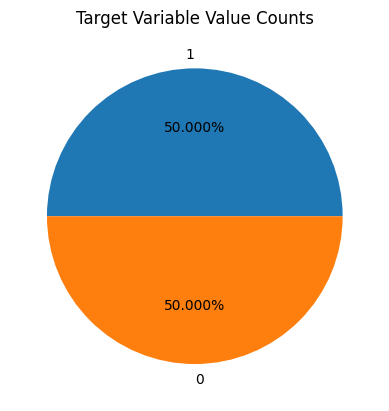

In [24]:
labels = df['Class'].unique()
sizes = df.Class.value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%')
ax.set_title('Target Variable Value Counts')
plt.show()

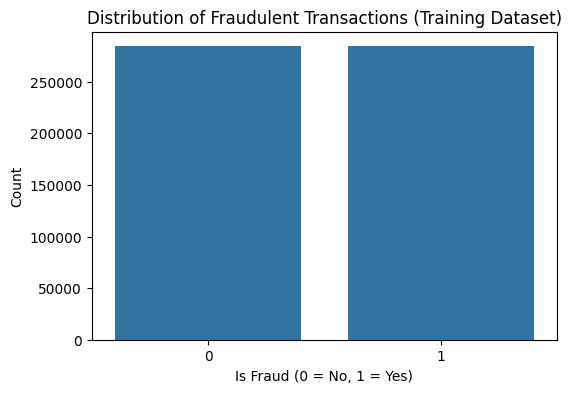

In [25]:
# Distribution of the target variable ('is_fraud') in the training dataset
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Fraudulent Transactions (Training Dataset)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

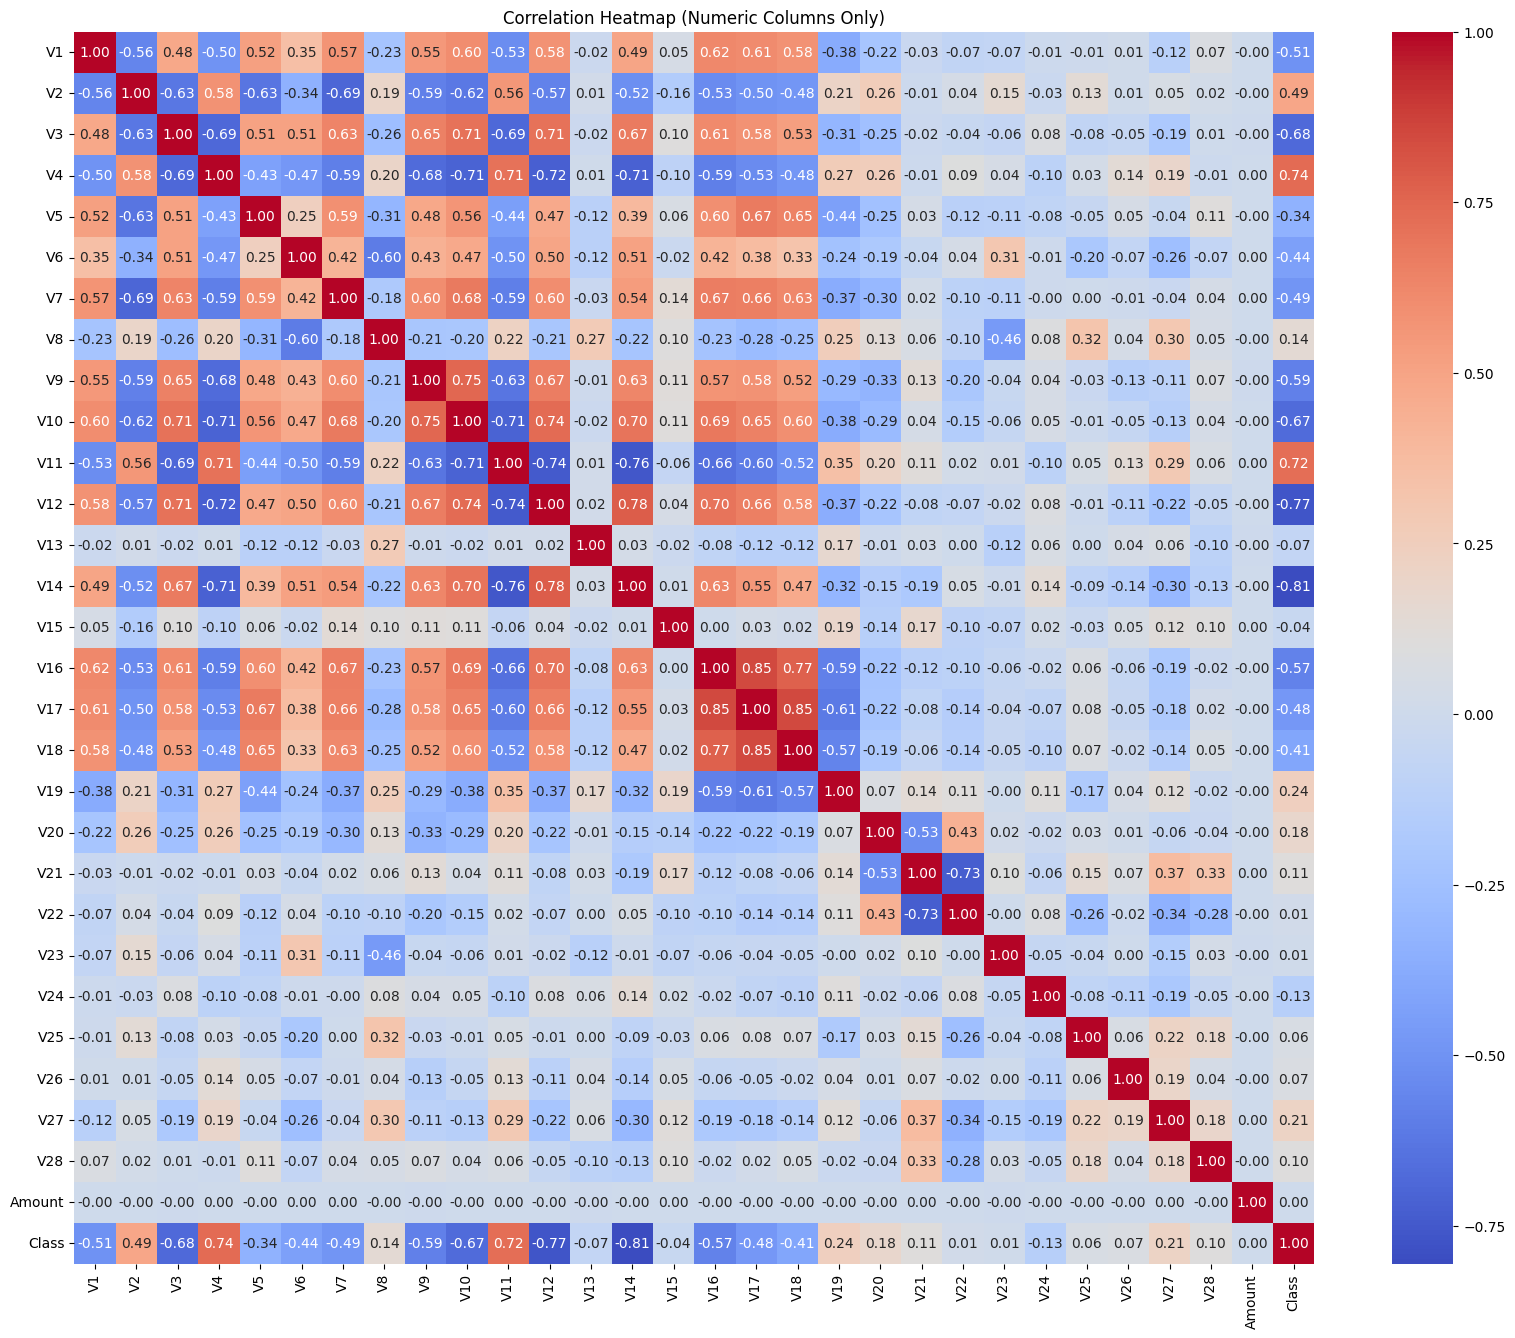

In [26]:
# Select only numeric columns for correlation analysis
numeric_data = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Columns Only)')
plt.show()

In [27]:
data.X_train

array([[0.88936643, 0.90883816, 0.18543587, ..., 0.08367216, 0.3352493 ,
        0.43946666],
       [0.49535225, 0.88858373, 0.29133602, ..., 0.08747733, 0.32981917,
        0.80821195],
       [0.43549888, 0.91922664, 0.13543036, ..., 0.09604541, 0.33984089,
        0.28084337],
       ...,
       [0.56850907, 0.91808762, 0.2385906 , ..., 0.08260601, 0.33426246,
        0.2097681 ],
       [0.89744757, 0.90717727, 0.20287601, ..., 0.08261799, 0.33363293,
        0.66653536],
       [0.92819969, 0.91135641, 0.16801113, ..., 0.08203706, 0.33310647,
        0.6173322 ]])

In [28]:
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.420468,-0.070194,-0.569266,0.191673,-0.009607,0.426903,-0.356728,0.096143,0.077806,-0.673283,...,0.235116,0.134969,0.070433,0.047770,-0.851622,0.102876,-0.375436,0.820807,0.665983,8633.18
1,-0.238944,0.250929,-0.374408,0.152938,-0.105008,-0.039028,-0.293004,0.133771,-0.591631,-0.651518,...,0.332143,0.192405,0.289441,-0.255187,-0.817462,0.308284,1.582688,0.574425,0.478489,12299.55
2,-0.117796,-0.147961,2.130455,-0.325762,0.325616,0.271351,0.772625,-0.244342,1.240012,0.414358,...,0.110696,-0.271739,-0.404654,-0.121235,0.857659,0.541920,0.756534,-0.238177,-0.403038,5215.87
3,-0.855315,0.137014,-0.628116,0.613733,-0.643573,-0.664283,-0.880040,0.466586,-1.045508,-1.234377,...,0.552311,0.405505,0.167560,0.446262,-0.205976,0.492582,0.658619,1.609128,-0.025592,19282.98
4,0.257686,0.035247,-0.203112,0.506745,-0.242235,-0.192608,-0.289297,0.044488,-0.396122,-0.370119,...,0.124330,0.162191,0.165912,-0.181999,0.331451,1.043095,0.029799,0.643273,0.736723,19114.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,0.801394,-0.816327,0.940860,-1.307453,-0.230994,0.075694,0.244866,-0.139237,1.758674,0.227288,...,0.010923,-0.002396,0.584551,-0.227596,1.335762,0.530426,0.174842,-0.220402,-0.009268,22404.20
568626,-0.094106,-0.396178,0.074629,-1.323275,1.240080,2.411076,0.286226,0.176478,0.752125,0.352242,...,-0.470184,-0.088351,-0.061028,0.224966,1.474007,-2.553339,-1.994806,-0.161470,0.230890,5736.76
568627,-0.986032,-0.241328,-0.805454,0.965279,-0.219016,-1.266523,-1.079518,0.414023,-0.870494,-1.062230,...,-0.139560,0.338603,0.119022,-1.152134,-0.766088,-0.706450,-0.358638,2.010951,0.814228,18943.99
568628,0.136515,-0.130872,1.506084,-0.414279,0.398608,-0.013919,0.872089,-0.239818,0.220758,0.511825,...,-0.155681,-0.082135,0.290838,-0.313113,0.854173,0.306760,-0.967220,-0.372687,-0.575555,6836.59


## Initializing The Enhanced BBOA Algorithm and Feature Selection Model

In [29]:
# ------------ Updated Enhanced BBOA Feature Selector ---------------- #

class EnhancedBBOAFeatureSelector:
    def __init__(self,
                 n_agents=20,
                 max_iter=30,
                 initial_exploration_rate=0.5,
                 r_min=0.1,
                 r_max=1.0,
                 boundaries=(0, 1),
                 classifier=None,
                 cv_folds=5,
                 save_dir="./enhanced_bboa_results",
                 random_state=None,
                 verbose=True,
                 plot_convergence=True):
        
        self.n_agents = n_agents
        self.max_iter = max_iter
        self.initial_exploration_rate = initial_exploration_rate
        self.r_min = r_min
        self.r_max = r_max
        self.boundaries = boundaries
        self.classifier = classifier
        self.cv_folds = cv_folds
        self.save_dir = save_dir
        self.random_state = random_state
        self.verbose = verbose

        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)
        
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        self.history = []

    def _initialize_population(self, dim):
        return np.random.uniform(self.boundaries[0], self.boundaries[1], (self.n_agents, dim))

    def _evaluate_fitness(self, population, X, y):
        fitness = np.zeros(self.n_agents)
        for i in range(self.n_agents):
            mask = population[i] > 0.5
            if np.sum(mask) == 0:
                fitness[i] = np.inf  # Penalize invalid solutions
                continue

            X_selected = X[:, mask]
            scores = cross_val_score(self.classifier, X_selected, y, cv=self.cv_folds)
            fitness[i] = 1.0 - np.mean(scores)  # Lower fitness is better
        return fitness

    def _calculate_diversity(self, population):
        return np.mean(np.std(population, axis=0))

    def _select_best_and_worst(self, population, fitness):
        best_idx = np.argmin(fitness)
        worst_idx = np.argmax(fitness)
        return population[best_idx], population[worst_idx]

    def _enhance_exploration(self, population, best_bear, worst_bear, alpha_k, r_k, theta_k):
        new_population = np.copy(population)
        for i in range(self.n_agents):
            rand_vector = np.random.uniform(-1, 1, size=population.shape[1])
            if 0 < theta_k <= 1/3:
                new_population[i] += alpha_k * rand_vector * r_k
            elif 1/3 < theta_k <= 2/3:
                new_population[i] += (alpha_k / 2) * rand_vector * r_k
            else:
                new_population[i] += (alpha_k / 5) * rand_vector * r_k

            new_population[i] = np.clip(new_population[i], self.boundaries[0], self.boundaries[1])
        return new_population

    def _adaptive_sniffing(self, population, fitness, diversity, diversity_threshold=0.1):
        new_population = np.copy(population)
        for i in range(self.n_agents):
            mate_idx = np.random.choice([idx for idx in range(self.n_agents) if idx != i])
            if diversity < diversity_threshold:
                if fitness[i] > fitness[mate_idx]:
                    new_population[i] = (population[i] + population[mate_idx]) / 2
            else:
                rand_factor = np.random.uniform(0, 1)
                new_population[i] = rand_factor * population[i] + (1 - rand_factor) * population[mate_idx]
            
            new_population[i] = np.clip(new_population[i], self.boundaries[0], self.boundaries[1])
        return new_population

    def fit(self, X, y):
        """
        Fit the Enhanced BBOA algorithm to select features.
        """
        dim = X.shape[1]
        P = self._initialize_population(dim)
        fitness = self._evaluate_fitness(P, X, y)
    
        f_best = np.min(fitness)
        P_best = P[np.argmin(fitness)]
    
        for k in range(1, self.max_iter + 1):
            start_time = time.time()  # Start timing the epoch
            theta_k = k / self.max_iter
            alpha_k = self.initial_exploration_rate * (1 - theta_k)
            r_k = self.r_min + (self.r_max - self.r_min) * (1 - theta_k)
    
            # Step 1: Enhance Exploration
            best_bear, worst_bear = self._select_best_and_worst(P, fitness)
            new_P = self._enhance_exploration(P, best_bear, worst_bear, alpha_k, r_k, theta_k)
            new_fitness = self._evaluate_fitness(new_P, X, y)
    
            # Step 2: Greedy Replacement after Exploration
            for i in range(self.n_agents):
                if new_fitness[i] < fitness[i]:  # lower fitness is better
                    P[i] = new_P[i]
                    fitness[i] = new_fitness[i]
    
            # Step 3: Update Best
            current_best_idx = np.argmin(fitness)
            if fitness[current_best_idx] < f_best:
                f_best = fitness[current_best_idx]
                P_best = P[current_best_idx]
    
            # Step 4: Calculate Diversity
            diversity = self._calculate_diversity(P)
    
            # Step 5: Adaptive Sniffing
            new_P = self._adaptive_sniffing(P, fitness, diversity)
            new_fitness = self._evaluate_fitness(new_P, X, y)
    
            # Step 6: Greedy Replacement after Sniffing
            for i in range(self.n_agents):
                if new_fitness[i] < fitness[i]:
                    P[i] = new_P[i]
                    fitness[i] = new_fitness[i]
    
            # Step 7: Update Best Again
            current_best_idx = np.argmin(fitness)
            if fitness[current_best_idx] < f_best:
                f_best = fitness[current_best_idx]
                P_best = P[current_best_idx]
    
            self.history.append(f_best)
            
            # Calculate elapsed time
            elapsed_time = time.time() - start_time
    
            if self.verbose:
                print(f"Iteration {k}/{self.max_iter}, Best Fitness: {f_best:.6f}, Diversity: {diversity:.6f}, Time: {elapsed_time:.2f}s")
    
        self.best_fitness = f_best
        self.best_agent = P_best
        self._save_best_agent()
    
        if self.plot_convergence:
            self.plot_convergence()


    def transform(self, X):
        """
        Transform the dataset using the selected features.

        Parameters:
            X : ndarray
                Input dataset of shape (n_samples, n_features).

        Returns:
            X_selected : ndarray
                Dataset with selected features only.
        """
        if self.best_agent is None:
            raise Exception("Model has not been fitted yet. Call `fit` first.")
            
        mask = self.best_agent > 0.5
        return X[:, mask]

    def fit_transform(self, X, y):
        """
        Fit the model and transform the dataset.

        Parameters:
            X : ndarray
                Input dataset of shape (n_samples, n_features).

        Returns:
            X_selected : ndarray
                Dataset with selected features.
        """
        self.fit(X, y)
        return self.transform(X)

    def _save_best_agent(self):
        np.save(os.path.join(self.save_dir, "best_agent.npy"), self.best_agent)
        summary = {
            "selected_features_count": int(np.sum(self.best_agent > 0.5)),
            "total_features": int(len(self.best_agent)),
            "best_fitness_score": float(self.best_fitness),
            "cv_folds": self.cv_folds
        }
        with open(os.path.join(self.save_dir, "summary.json"), "w") as f:
            json.dump(summary, f, indent=4)

    def get_selected_indices(self):
        return np.where(self.best_agent > 0.5)[0]

    def plot_convergence(self):
        """
        Plot the convergence curve of the fitness over iterations.
        """
        plt.figure(figsize=(8, 5))
        plt.plot(self.history, label="Best Fitness")
        plt.xlabel("Iteration")
        plt.ylabel("Fitness")
        plt.title("Convergence Curve")
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(self.save_dir, "fitness_curve.png"))
        plt.show()

/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regressi

Iteration 1/30, Best Fitness: 0.040393, Diversity: 0.305146, Time: 103.33s
Iteration 2/30, Best Fitness: 0.039526, Diversity: 0.289506, Time: 100.78s


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Iteration 3/30, Best Fitness: 0.039232, Diversity: 0.276487, Time: 103.28s
Iteration 4/30, Best Fitness: 0.039232, Diversity: 0.274814, Time: 97.44s


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



...

Iteration 6/30, Best Fitness: 0.039232, Diversity: 0.229837, Time: 114.27s


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regressi

Iteration 7/30, Best Fitness: 0.039232, Diversity: 0.205450, Time: 113.70s
Iteration 8/30, Best Fitness: 0.039232, Diversity: 0.173831, Time: 111.04s
Iteration 9/30, Best Fitness: 0.039232, Diversity: 0.169452, Time: 107.05s


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



Iteration 10/30, Best Fitness: 0.039232, Diversity: 0.163086, Time: 111.47s
Iteration 11/30, Best Fitness: 0.039102, Diversity: 0.158555, Time: 121.05s
Iteration 12/30, Best Fitness: 0.039102, Diversity: 0.155425, Time: 127.78s
Iteration 13/30, Best Fitness: 0.039102, Diversity: 0.130148, Time: 123.78s
Iteration 14/30, Best Fitness: 0.039011, Diversity: 0.125652, Time: 123.55s
Iteration 15/30, Best Fitness: 0.039011, Diversity: 0.123334, Time: 115.25s
Iteration 16/30, Best Fitness: 0.039011, Diversity: 0.120851, Time: 122.48s
Iteration 17/30, Best Fitness: 0.039011, Diversity: 0.114163, Time: 1015.49s
Iteration 18/30, Best Fitness: 0.039011, Diversity: 0.105318, Time: 118.57s
Iteration 19/30, Best Fitness: 0.039011, Diversity: 0.098735, Time: 1032.19s
Iteration 20/30, Best Fitness: 0.039011, Diversity: 0.096443, Time: 114.38s
Iteration 21/30, Best Fitness: 0.039011, Diversity: 0.091249, Time: 1110.49s
Iteration 22/30, Best Fitness: 0.039011, Diversity: 0.091022, Time: 111.35s
Iteration

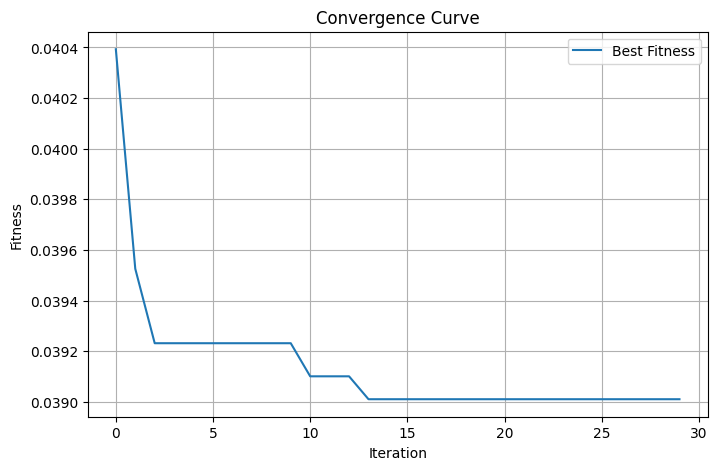

Original features: 29
Selected features: 21


In [30]:
# Initialize Enhanced BBOA Feature Selector
enhanced_bboa_selector = EnhancedBBOAFeatureSelector(
    n_agents=20,
    max_iter=30,
    initial_exploration_rate=0.5,
    classifier=LogisticRegression(),
    cv_folds=5,
    save_dir="./enhanced_bboa_results",
    random_state=42
)

# Fit and transform your data
X_train_selected = enhanced_bboa_selector.fit_transform(data.X_train, data.y_train)

# Reduce X_test as well
selected_indices = enhanced_bboa_selector.get_selected_indices()
X_test_selected = data.X_test[:, selected_indices]

print(f"Original features: {data.X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

In [31]:
X_train_selected.shape[1]

21

In [32]:
X_test_selected

array([[0.53222217, 0.16399166, 0.58259243, ..., 0.71325634, 0.42376439,
        0.20279115],
       [0.59320714, 0.24031859, 0.48408825, ..., 0.69646972, 0.37276829,
        0.36781751],
       [0.58703639, 0.26061179, 0.40901203, ..., 0.70449366, 0.40498151,
        0.21172623],
       ...,
       [0.59823568, 0.1559492 , 0.57218413, ..., 0.70738924, 0.38996557,
        0.16350029],
       [0.65063096, 0.21748853, 0.4841892 , ..., 0.69764617, 0.34803269,
        0.22497595],
       [0.5415363 , 0.20422471, 0.60257528, ..., 0.70614352, 0.39326796,
        0.31201333]])

In [33]:
# --------- Simple SNN Model for Classification ------------- #

# -------- Surrogate Function --------
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return (input >= 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad_input = grad_output.clone()
        # surrogate gradient: d(ReLU)/dx (approximate)
        surrogate_grad = torch.sigmoid(5 * input) * (1 - torch.sigmoid(5 * input))
        return grad_input * surrogate_grad

surrogate_spike_fn = SurrogateSpike.apply

# -------- Updated SNNLayer --------
class SNNLayer(nn.Module):
    def __init__(self, in_features, out_features, threshold=1.0, decay=0.9):
        super(SNNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)
        self.threshold = threshold
        self.decay = decay
        self.mem = None

    def forward(self, x):
        if self.mem is None:
            self.mem = torch.zeros(x.size(0), self.fc.out_features, device=x.device)

        current = self.fc(x)
        self.mem = self.mem * self.decay + current
        spike = surrogate_spike_fn(self.mem - self.threshold)
        self.mem = self.mem * (1 - spike)  # reset after spike
        return spike

    def reset(self):
        self.mem = None

# -------- Updated SNNClassifier --------
class SNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, threshold=1.0):
        super(SNNClassifier, self).__init__()
        self.snn1 = SNNLayer(input_dim, hidden_dim, threshold=threshold)
        self.snn2 = SNNLayer(hidden_dim, output_dim, threshold=threshold)

    def forward(self, x, time_steps=20):
        out_spikes = torch.zeros(x.size(0), self.snn2.fc.out_features, device=x.device)
        for t in range(time_steps):
            spike1 = self.snn1(x)
            spike2 = self.snn2(spike1)
            out_spikes += spike2
        return out_spikes  # output spike counts (higher means more confident)

    def reset(self):
        self.snn1.reset()
        self.snn2.reset()

# -------- Updated SNNTrainer --------
class SNNTrainer:
    def __init__(self, model, lr=1e-3, epochs=30, batch_size=32, device=None):
        self.model = model
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.losses = []

    def fit(self, X_train, y_train):
        X_train = torch.tensor(X_train, dtype=torch.float32)
        y_train = torch.tensor(y_train, dtype=torch.long)

        dataset = torch.utils.data.TensorDataset(X_train, y_train)
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(self.epochs):
            
            start_time = time.time()
            
            self.model.train()
            epoch_loss = 0
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)

                self.model.reset()
                out = self.model(xb)

                loss = criterion(out, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            avg_epoch_loss = epoch_loss / len(loader)
            self.losses.append(avg_epoch_loss)

             # Calculate elapsed time
            elapsed_time = time.time() - start_time

            print(f"Epoch {epoch+1}/{self.epochs}, Loss: {avg_epoch_loss:.4f}, Time: {elapsed_time:.2f}s")

    def plot_training_loss(self):
        plt.figure(figsize=(8,6))
        plt.plot(self.losses, label="Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Curve")
        plt.legend()
        plt.grid()
        plt.show()

    def evaluate(self, X_test, y_test):
        self.model.eval()
        X_test = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        y_test = torch.tensor(y_test, dtype=torch.long).to(self.device)
    
        self.model.reset()
        out = self.model(X_test)  # raw logits or probabilities
        preds = torch.argmax(out, dim=1)
    
        y_true = y_test.cpu().numpy()
        y_pred = preds.cpu().numpy()
    
        # Metrics
        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted")
        recall = recall_score(y_true, y_pred, average="weighted")
        f1 = f1_score(y_true, y_pred, average="weighted")
    
        # MCC
        mcc = matthews_corrcoef(y_true, y_pred)
    
        # AUC-ROC Score (binary or one-vs-rest)
        if out.shape[1] == 2:
            probs = torch.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
            auc_roc = roc_auc_score(y_true, probs)
            
            # Plot ROC curve
            fpr, tpr, _ = roc_curve(y_true, probs)
            plt.figure()
            plt.plot(fpr, tpr, label=f'AUC = {auc_roc:.4f}')
            plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC Curve')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            auc_roc = roc_auc_score(y_true, out.detach().cpu().numpy(), multi_class='ovr', average='weighted')
    
        # Print Metrics
        print("\nClassification Report:\n", classification_report(y_true, y_pred))
        print("Accuracy:", acc)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1 Score:", f1)
        print("MCC:", mcc)
        print("AUC-ROC Score:", auc_roc)
    
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    
        return acc, precision, recall, f1, mcc, auc_roc

    def save_model(self, path="./snn_model.pth"):
        torch.save(self.model.state_dict(), path)

    def load_model(self, path="./snn_model.pth"):
        self.model.load_state_dict(torch.load(path, map_location=self.device))

Epoch 1/30, Loss: 0.1099, Time: 60.82s
Epoch 2/30, Loss: 0.0838, Time: 61.81s
Epoch 3/30, Loss: 0.0760, Time: 60.57s
Epoch 4/30, Loss: 0.0699, Time: 60.36s
Epoch 5/30, Loss: 0.0656, Time: 961.77s
Epoch 6/30, Loss: 0.0642, Time: 479.50s
Epoch 7/30, Loss: 0.0593, Time: 60.76s
Epoch 8/30, Loss: 0.0603, Time: 60.02s
Epoch 9/30, Loss: 0.0557, Time: 60.78s
Epoch 10/30, Loss: 0.0544, Time: 60.38s
Epoch 11/30, Loss: 0.0509, Time: 60.41s
Epoch 12/30, Loss: 0.0503, Time: 60.46s
Epoch 13/30, Loss: 0.0477, Time: 60.22s
Epoch 14/30, Loss: 0.0460, Time: 60.40s
Epoch 15/30, Loss: 0.0438, Time: 57.18s
Epoch 16/30, Loss: 0.0491, Time: 60.93s
Epoch 17/30, Loss: 0.0457, Time: 60.71s
Epoch 18/30, Loss: 0.0431, Time: 60.87s
Epoch 19/30, Loss: 0.0418, Time: 60.81s
Epoch 20/30, Loss: 0.0407, Time: 60.73s
Epoch 21/30, Loss: 0.0394, Time: 61.28s
Epoch 22/30, Loss: 0.0387, Time: 60.73s
Epoch 23/30, Loss: 0.0381, Time: 61.60s
Epoch 24/30, Loss: 0.0380, Time: 60.94s
Epoch 25/30, Loss: 0.0389, Time: 60.82s
Epoch 2

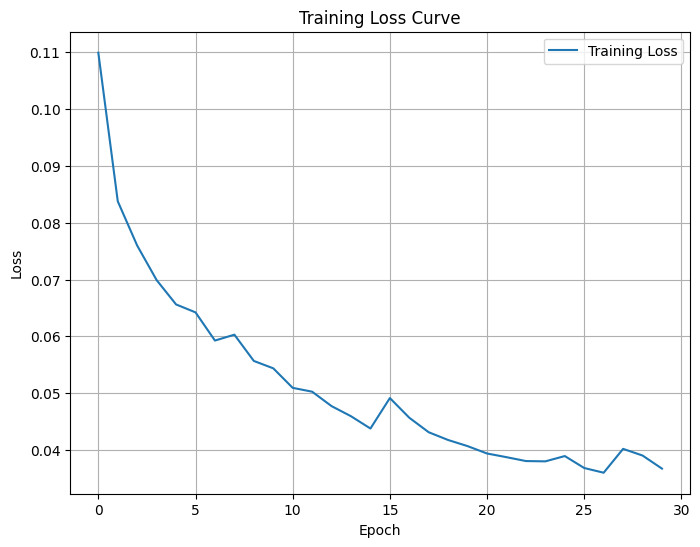

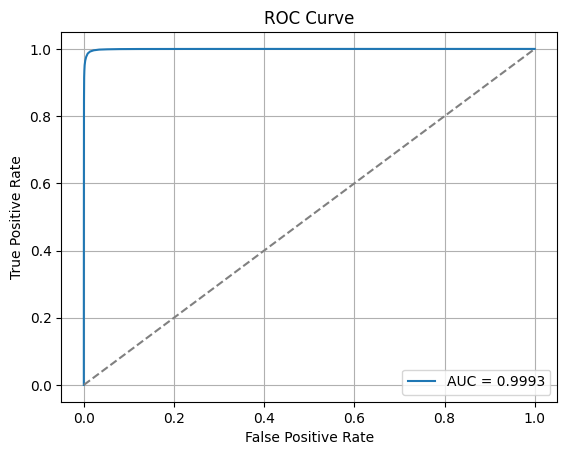


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     85295
           1       0.99      0.99      0.99     85294

    accuracy                           0.99    170589
   macro avg       0.99      0.99      0.99    170589
weighted avg       0.99      0.99      0.99    170589

Accuracy: 0.9891845312417565
Precision: 0.9892025049197904
Recall: 0.9891845312417565
F1 Score: 0.9891844320929437
MCC: 0.9783870363800108
AUC-ROC Score: 0.9993173173310572


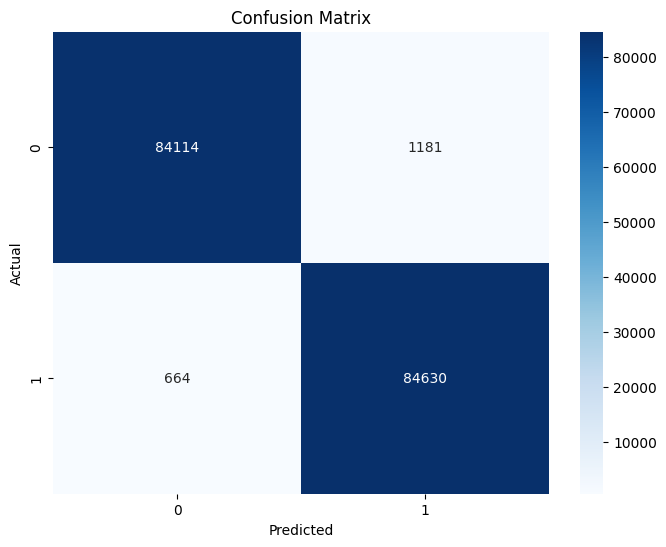

In [34]:
# Initialize
input_dim = X_train_selected.shape[1]
hidden_dim = 128
output_dim = len(np.unique(data.y_train))  # number of classes

snn_model = SNNClassifier(input_dim, hidden_dim, output_dim)

# Train
trainer = SNNTrainer(snn_model, lr=0.001, epochs=30, batch_size=32)
trainer.fit(X_train_selected, data.y_train)

# Plot Training Loss
trainer.plot_training_loss()

# Evaluate
trainer.evaluate(X_test_selected, data.y_test)

# Save Model
trainer.save_model("./bboa_selected_snn_model.pth")